# Step 5: Data Visualizations

This notebook creates key visualizations for commodity trading analysis:
- Price movements over time
- Forward curve spreads (contango vs backwardation)
- Roll pressure (money flow)
- Ending stocks (fundamental reality)
- Spread vs stocks relationship
- Returns under different supply regimes
- Volume & OI dominance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set style (using matplotlib's built-in style, no seaborn required)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    # Fallback to default style with manual grid settings
    plt.style.use('default')
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['axes.axisbelow'] = True

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

BASE_PATH = "/Users/aryansinha/Desktop/WASDA"

# Load WASDE-aligned data
corn = pd.read_csv(
    f"{BASE_PATH}/processed/wasde_aligned/corn_wasde.csv",
    parse_dates=["date"]
)
soy = pd.read_csv(
    f"{BASE_PATH}/processed/wasde_aligned/soy_wasde.csv",
    parse_dates=["date"]
)
wheat = pd.read_csv(
    f"{BASE_PATH}/processed/wasde_aligned/wheat_wasde.csv",
    parse_dates=["date"]
)

print("Data loaded:")
print(f"Corn:  {corn.shape}")
print(f"Soy:   {soy.shape}")
print(f"Wheat: {wheat.shape}")


Data loaded:
Corn:  (1259, 29)
Soy:   (1260, 29)
Wheat: (1259, 29)


## GRAPH 1 — Price Over Time (Baseline)

Shows how the front-month futures price moves over time. This grounds the audience and gives context.


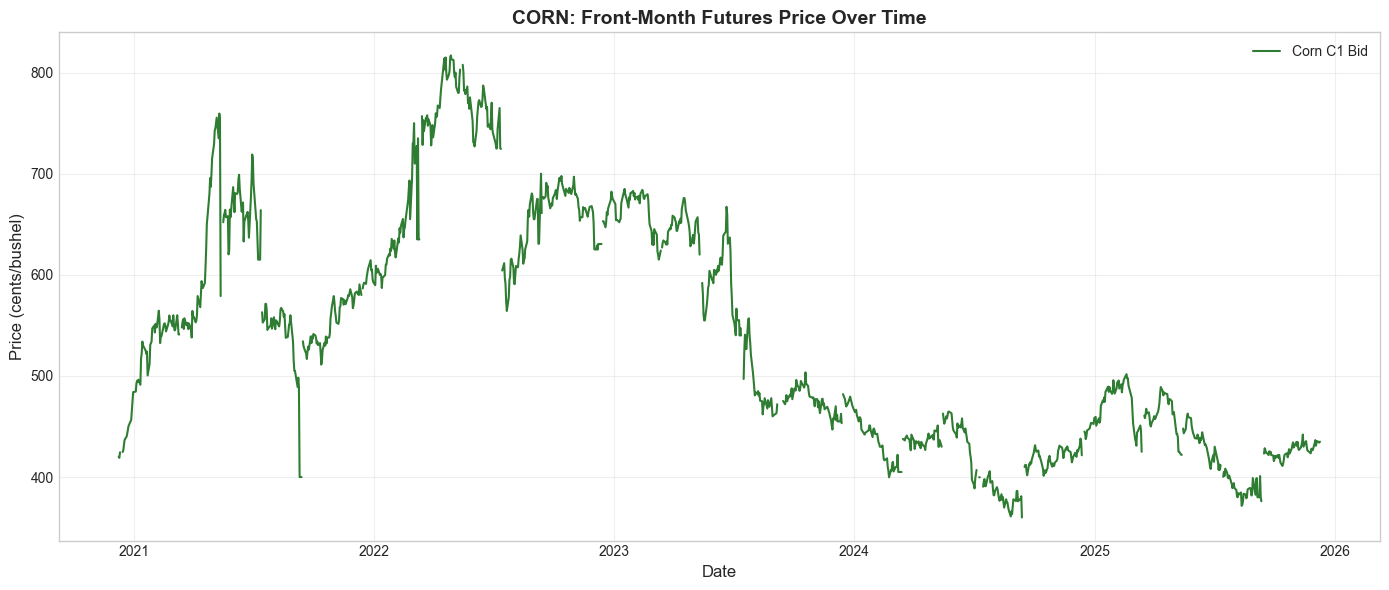

This shows how the front-month futures price moves over time.


In [2]:
# CORN: Price over time
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(corn['date'], corn['c1_bid'], linewidth=1.5, color='#2E7D32', label='Corn C1 Bid')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (cents/bushel)', fontsize=12)
ax.set_title('CORN: Front-Month Futures Price Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("This shows how the front-month futures price moves over time.")


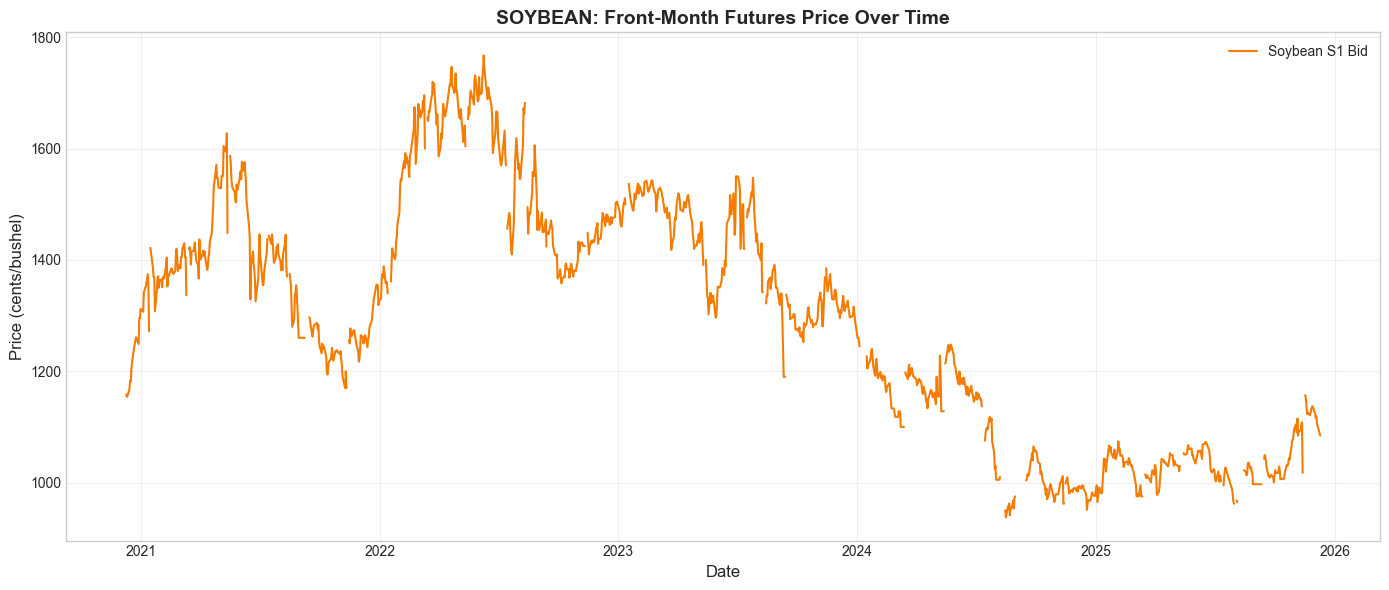

In [3]:
# SOYBEAN: Price over time
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(soy['date'], soy['s1_bid'], linewidth=1.5, color='#F57C00', label='Soybean S1 Bid')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (cents/bushel)', fontsize=12)
ax.set_title('SOYBEAN: Front-Month Futures Price Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


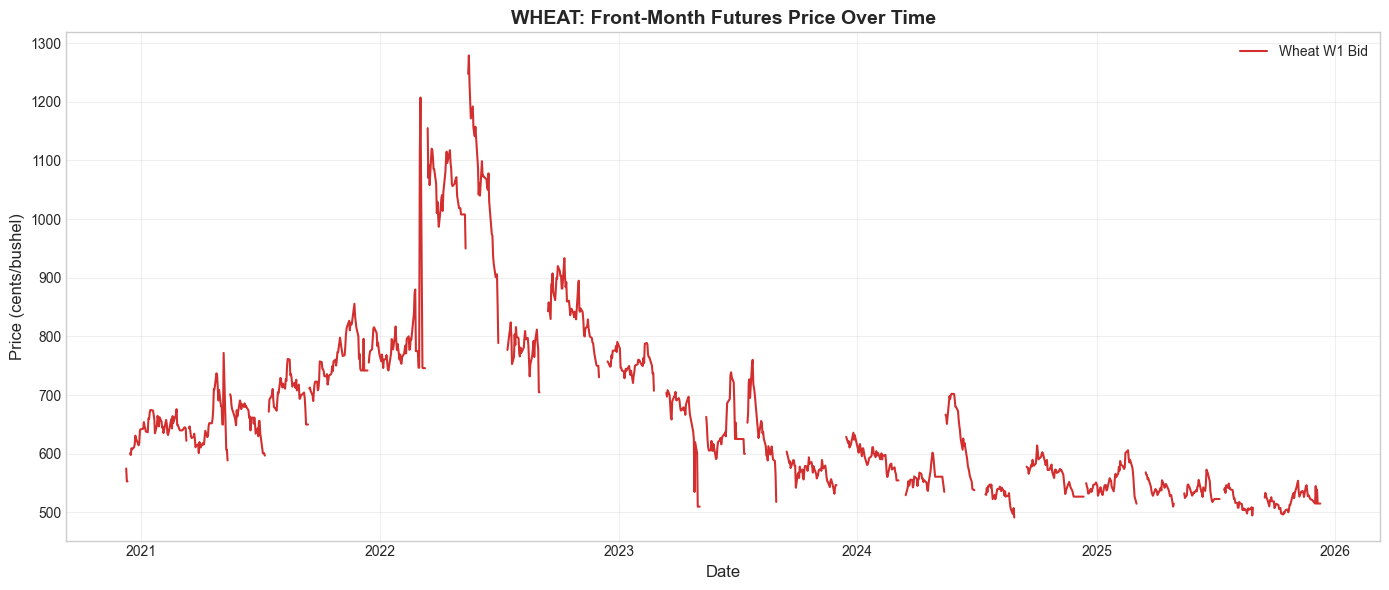

In [4]:
# WHEAT: Price over time
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wheat['date'], wheat['w1_bid'], linewidth=1.5, color='#D32F2F', label='Wheat W1 Bid')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (cents/bushel)', fontsize=12)
ax.set_title('WHEAT: Front-Month Futures Price Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## GRAPH 2 — Forward Curve Spread (C1 − C2)

Shows whether the market is in contango or backwardation.
- Above zero = backwardation (shortage now, front month premium)
- Below zero = contango (excess supply, back month premium)


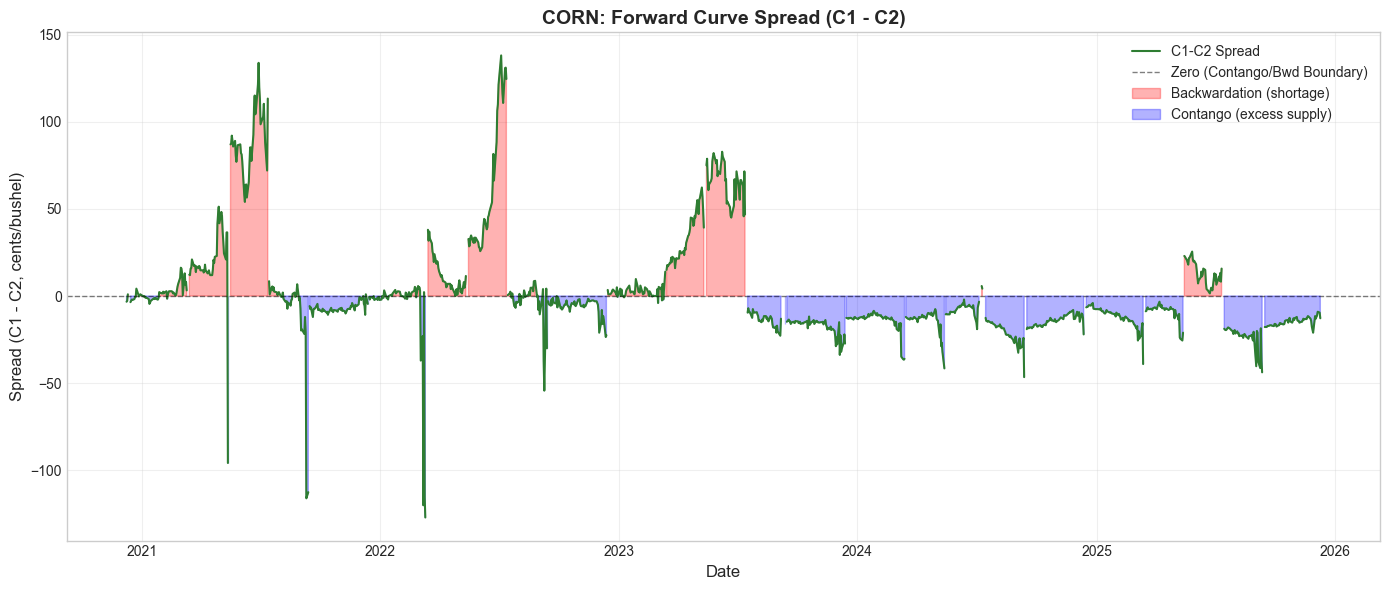

This shows whether the market is in contango or backwardation.
Above zero = shortage now (backwardation)
Below zero = excess supply (contango)


In [5]:
# CORN: Forward curve spread
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(corn['date'], corn['spread_c1_c2'], linewidth=1.5, color='#2E7D32', label='C1-C2 Spread')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Zero (Contango/Bwd Boundary)')
ax.fill_between(corn['date'], 0, corn['spread_c1_c2'], where=(corn['spread_c1_c2'] > 0), 
                alpha=0.3, color='red', label='Backwardation (shortage)')
ax.fill_between(corn['date'], 0, corn['spread_c1_c2'], where=(corn['spread_c1_c2'] < 0), 
                alpha=0.3, color='blue', label='Contango (excess supply)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Spread (C1 - C2, cents/bushel)', fontsize=12)
ax.set_title('CORN: Forward Curve Spread (C1 - C2)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("This shows whether the market is in contango or backwardation.")
print("Above zero = shortage now (backwardation)")
print("Below zero = excess supply (contango)")


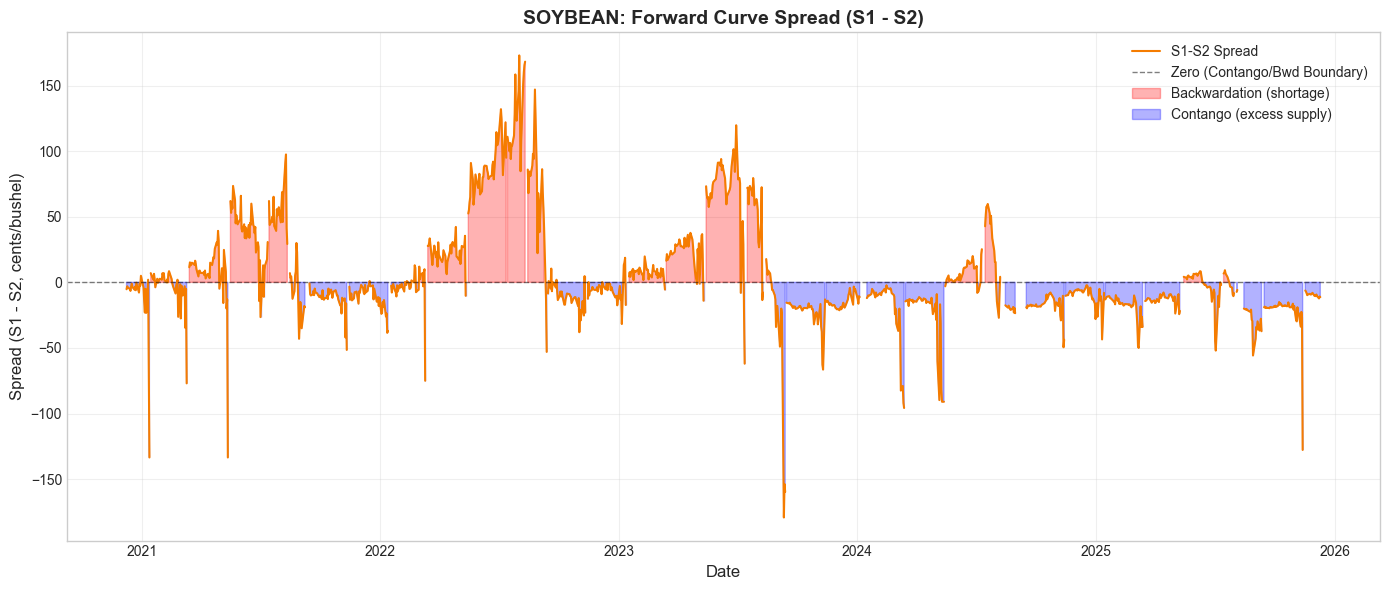

In [6]:
# SOYBEAN: Forward curve spread
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(soy['date'], soy['spread_c1_c2'], linewidth=1.5, color='#F57C00', label='S1-S2 Spread')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Zero (Contango/Bwd Boundary)')
ax.fill_between(soy['date'], 0, soy['spread_c1_c2'], where=(soy['spread_c1_c2'] > 0), 
                alpha=0.3, color='red', label='Backwardation (shortage)')
ax.fill_between(soy['date'], 0, soy['spread_c1_c2'], where=(soy['spread_c1_c2'] < 0), 
                alpha=0.3, color='blue', label='Contango (excess supply)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Spread (S1 - S2, cents/bushel)', fontsize=12)
ax.set_title('SOYBEAN: Forward Curve Spread (S1 - S2)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


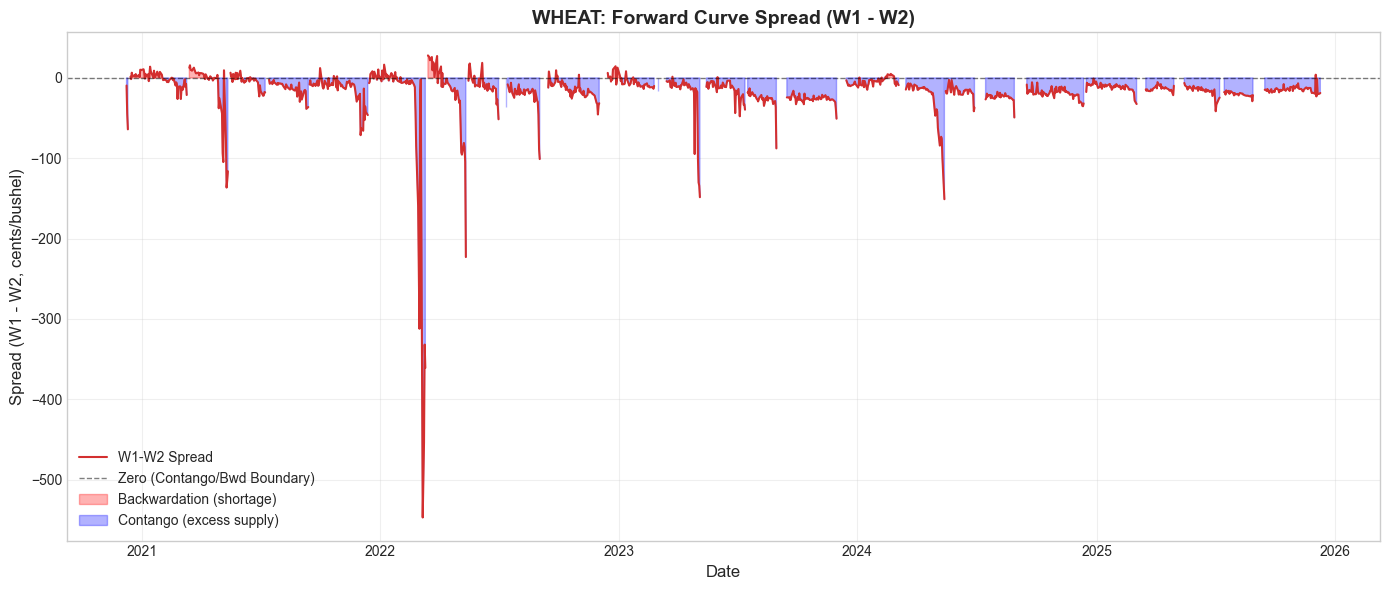

In [7]:
# WHEAT: Forward curve spread
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wheat['date'], wheat['spread_c1_c2'], linewidth=1.5, color='#D32F2F', label='W1-W2 Spread')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Zero (Contango/Bwd Boundary)')
ax.fill_between(wheat['date'], 0, wheat['spread_c1_c2'], where=(wheat['spread_c1_c2'] > 0), 
                alpha=0.3, color='red', label='Backwardation (shortage)')
ax.fill_between(wheat['date'], 0, wheat['spread_c1_c2'], where=(wheat['spread_c1_c2'] < 0), 
                alpha=0.3, color='blue', label='Contango (excess supply)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Spread (W1 - W2, cents/bushel)', fontsize=12)
ax.set_title('WHEAT: Forward Curve Spread (W1 - W2)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## GRAPH 3 — Roll Pressure (Money Flow)

Shows whether traders are moving into or out of the front contract. This demonstrates understanding of how futures actually trade.


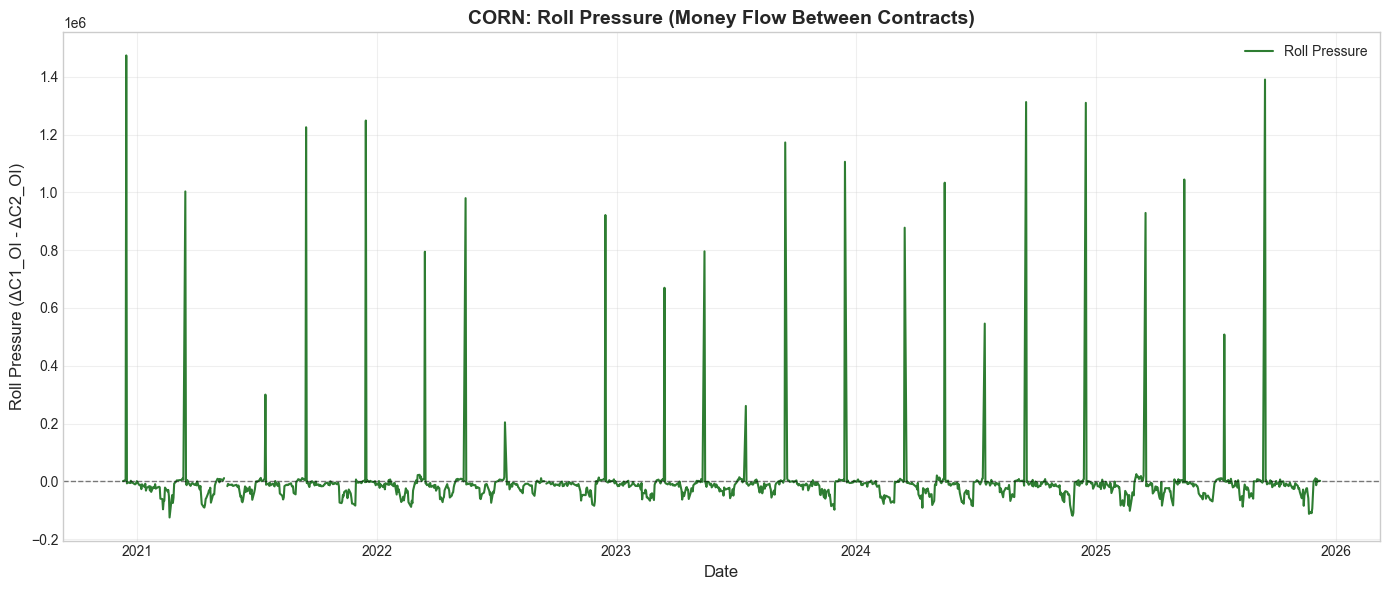

This shows whether traders are moving into or out of the front contract.


In [8]:
# CORN: Roll pressure
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(corn['date'], corn['roll_pressure'], linewidth=1.5, color='#2E7D32', label='Roll Pressure')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Roll Pressure (ΔC1_OI - ΔC2_OI)', fontsize=12)
ax.set_title('CORN: Roll Pressure (Money Flow Between Contracts)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("This shows whether traders are moving into or out of the front contract.")


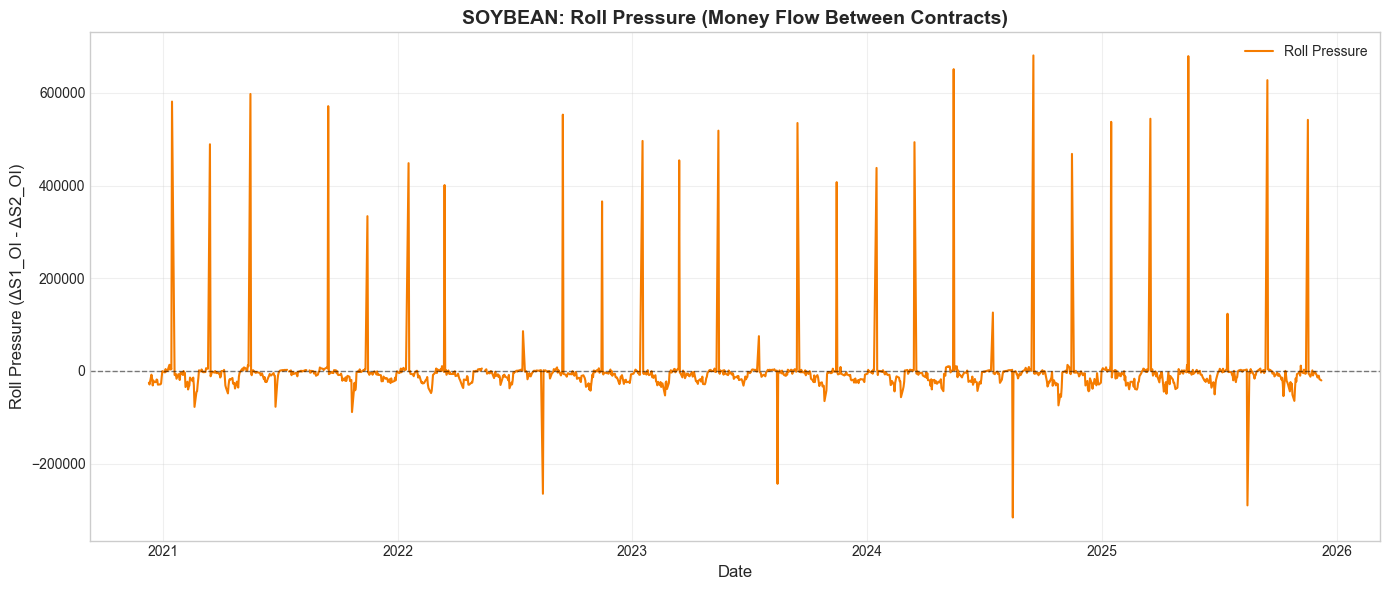

In [9]:
# SOYBEAN: Roll pressure
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(soy['date'], soy['roll_pressure'], linewidth=1.5, color='#F57C00', label='Roll Pressure')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Roll Pressure (ΔS1_OI - ΔS2_OI)', fontsize=12)
ax.set_title('SOYBEAN: Roll Pressure (Money Flow Between Contracts)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


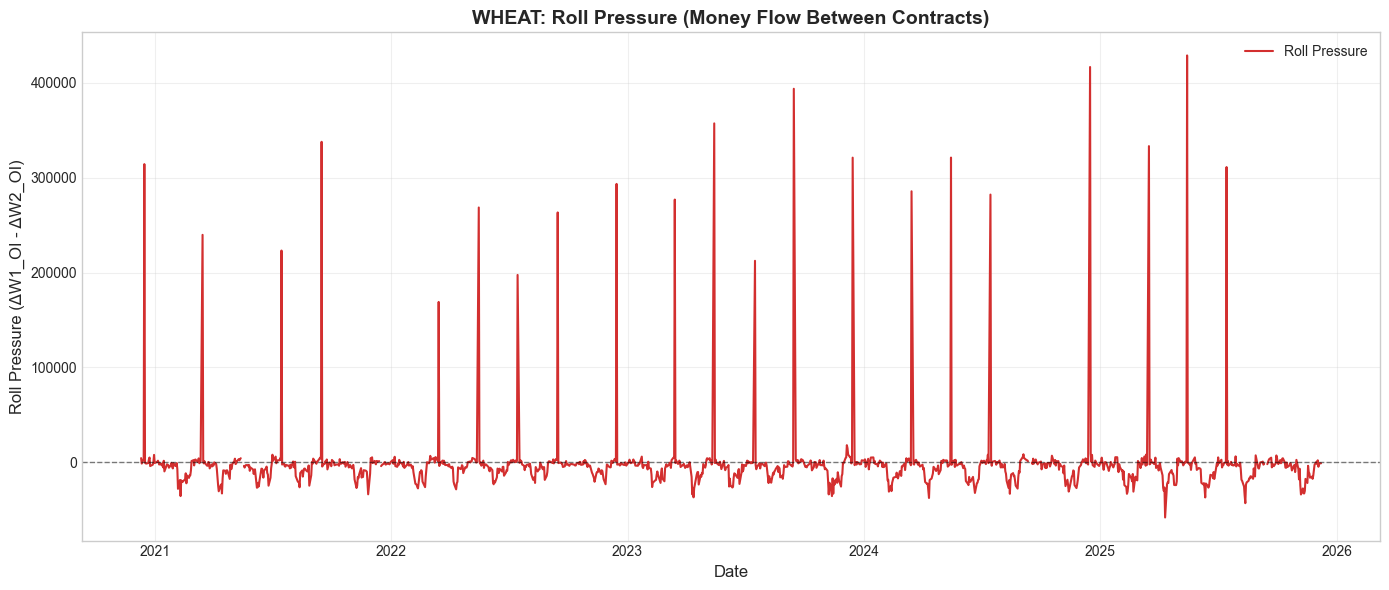

In [10]:
# WHEAT: Roll pressure
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wheat['date'], wheat['roll_pressure'], linewidth=1.5, color='#D32F2F', label='Roll Pressure')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Roll Pressure (ΔW1_OI - ΔW2_OI)', fontsize=12)
ax.set_title('WHEAT: Roll Pressure (Money Flow Between Contracts)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## GRAPH 4 — Ending Stocks Level (Fundamental Reality)

Shows how much supply the USDA says is left in the system. This connects paper data to real-world food.


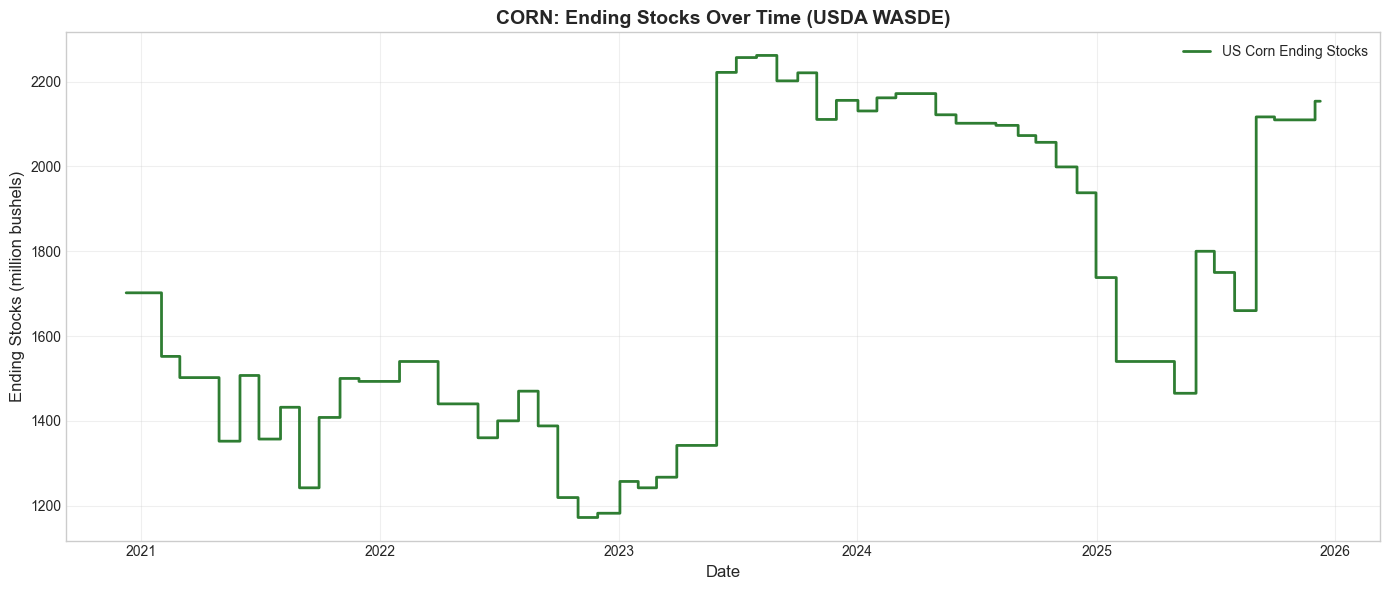

This shows how much supply the USDA says is left in the system.


In [11]:
# CORN: Ending stocks (step-style line)
fig, ax = plt.subplots(figsize=(14, 6))
ax.step(corn['date'], corn['ending_stocks'], where='post', linewidth=2, color='#2E7D32', label='US Corn Ending Stocks')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Ending Stocks (million bushels)', fontsize=12)
ax.set_title('CORN: Ending Stocks Over Time (USDA WASDE)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("This shows how much supply the USDA says is left in the system.")


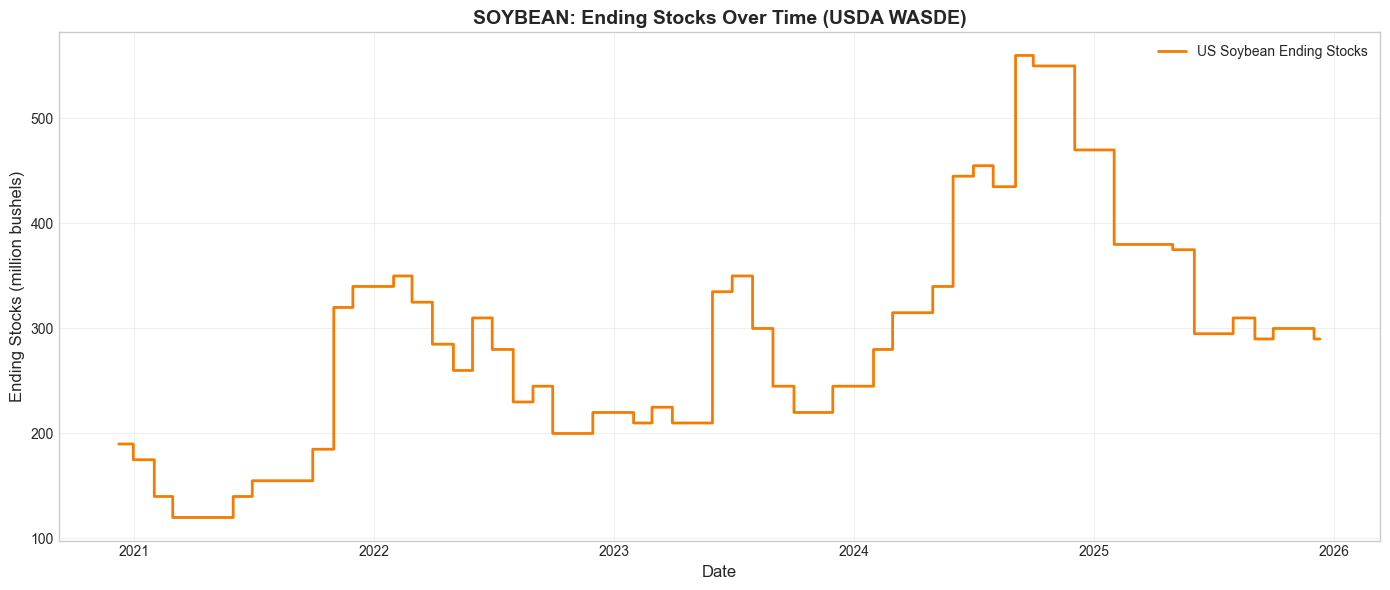

In [12]:
# SOYBEAN: Ending stocks (step-style line)
fig, ax = plt.subplots(figsize=(14, 6))
ax.step(soy['date'], soy['ending_stocks'], where='post', linewidth=2, color='#F57C00', label='US Soybean Ending Stocks')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Ending Stocks (million bushels)', fontsize=12)
ax.set_title('SOYBEAN: Ending Stocks Over Time (USDA WASDE)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


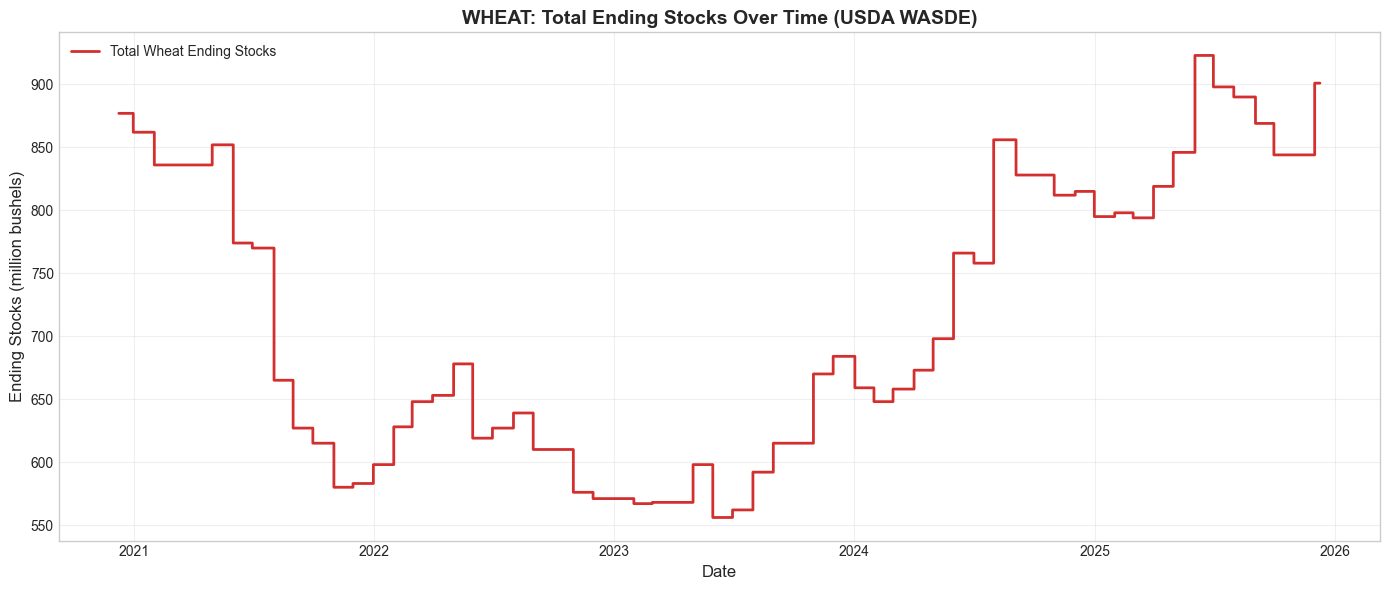

In [13]:
# WHEAT: Total ending stocks (step-style line)
fig, ax = plt.subplots(figsize=(14, 6))
ax.step(wheat['date'], wheat['ending_stocks_total'], where='post', linewidth=2, color='#D32F2F', label='Total Wheat Ending Stocks')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Ending Stocks (million bushels)', fontsize=12)
ax.set_title('WHEAT: Total Ending Stocks Over Time (USDA WASDE)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


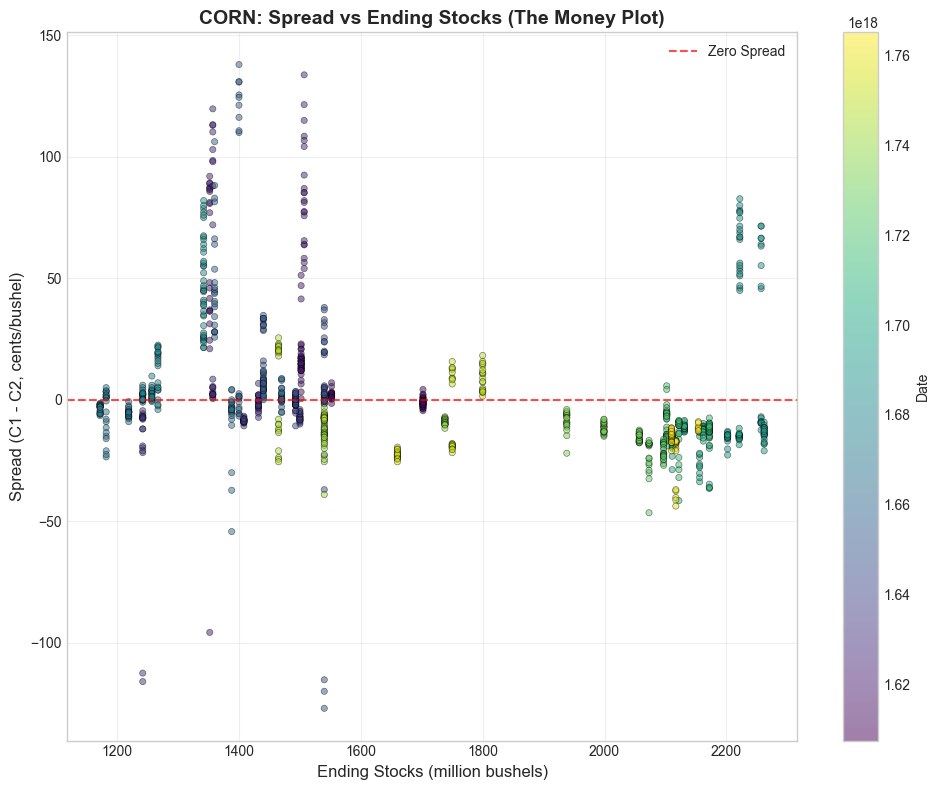

When supply is tight (low stocks), the curve tends to move into backwardation (positive spread).


In [14]:
# CORN: Spread vs Ending Stocks
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(corn['ending_stocks'], corn['spread_c1_c2'], 
                     alpha=0.5, s=20, c=corn['date'], cmap='viridis', edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero Spread')
ax.set_xlabel('Ending Stocks (million bushels)', fontsize=12)
ax.set_ylabel('Spread (C1 - C2, cents/bushel)', fontsize=12)
ax.set_title('CORN: Spread vs Ending Stocks (The Money Plot)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Date', fontsize=10)
plt.tight_layout()
plt.show()

print("When supply is tight (low stocks), the curve tends to move into backwardation (positive spread).")


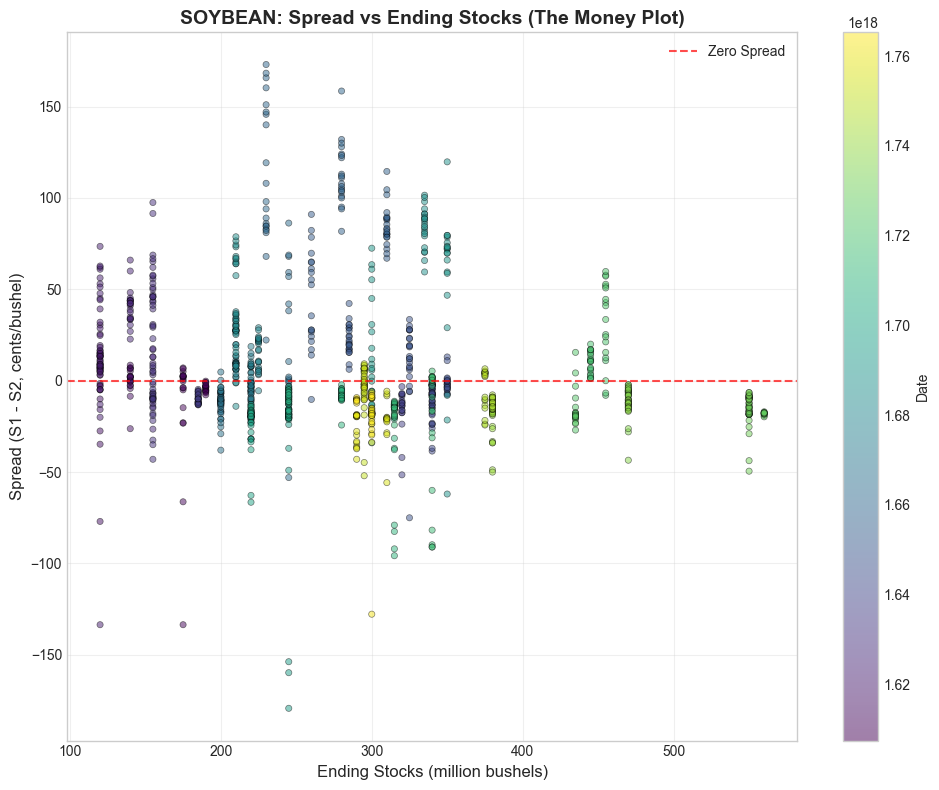

In [15]:
# SOYBEAN: Spread vs Ending Stocks
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(soy['ending_stocks'], soy['spread_c1_c2'], 
                     alpha=0.5, s=20, c=soy['date'], cmap='viridis', edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero Spread')
ax.set_xlabel('Ending Stocks (million bushels)', fontsize=12)
ax.set_ylabel('Spread (S1 - S2, cents/bushel)', fontsize=12)
ax.set_title('SOYBEAN: Spread vs Ending Stocks (The Money Plot)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Date', fontsize=10)
plt.tight_layout()
plt.show()


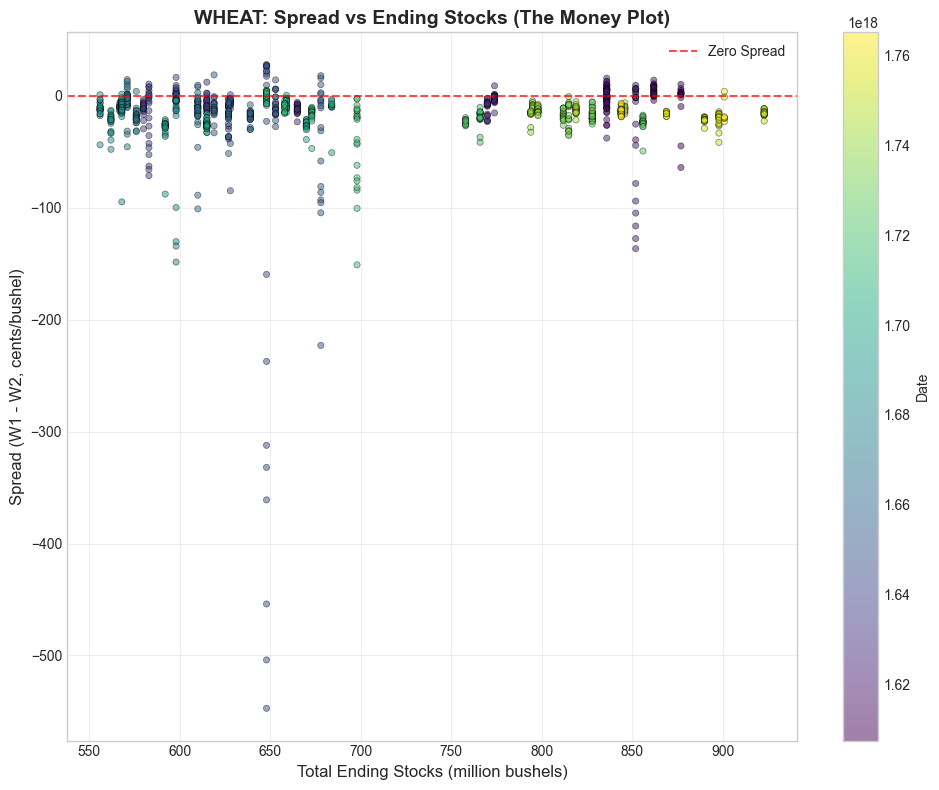

In [16]:
# WHEAT: Spread vs Ending Stocks
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(wheat['ending_stocks_total'], wheat['spread_c1_c2'], 
                     alpha=0.5, s=20, c=wheat['date'], cmap='viridis', edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero Spread')
ax.set_xlabel('Total Ending Stocks (million bushels)', fontsize=12)
ax.set_ylabel('Spread (W1 - W2, cents/bushel)', fontsize=12)
ax.set_title('WHEAT: Spread vs Ending Stocks (The Money Plot)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Date', fontsize=10)
plt.tight_layout()
plt.show()


## GRAPH 6 — Returns Under Different Regimes

Price behavior differs depending on supply conditions. This is the beginning of a strategy.


/var/folders/3j/0xbmd_c918x585z1bkf86vtw0000gn/T/ipykernel_36216/103975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corn_clean['stock_regime'] = pd.qcut(corn_clean['ending_stocks'], q=3, labels=['Low Stocks', 'Medium Stocks', 'High Stocks'])
/var/folders/3j/0xbmd_c918x585z1bkf86vtw0000gn/T/ipykernel_36216/103975.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  returns_by_regime = corn_clean.groupby('stock_regime')['ret_5d'].mean() * 100  # Convert to percentage


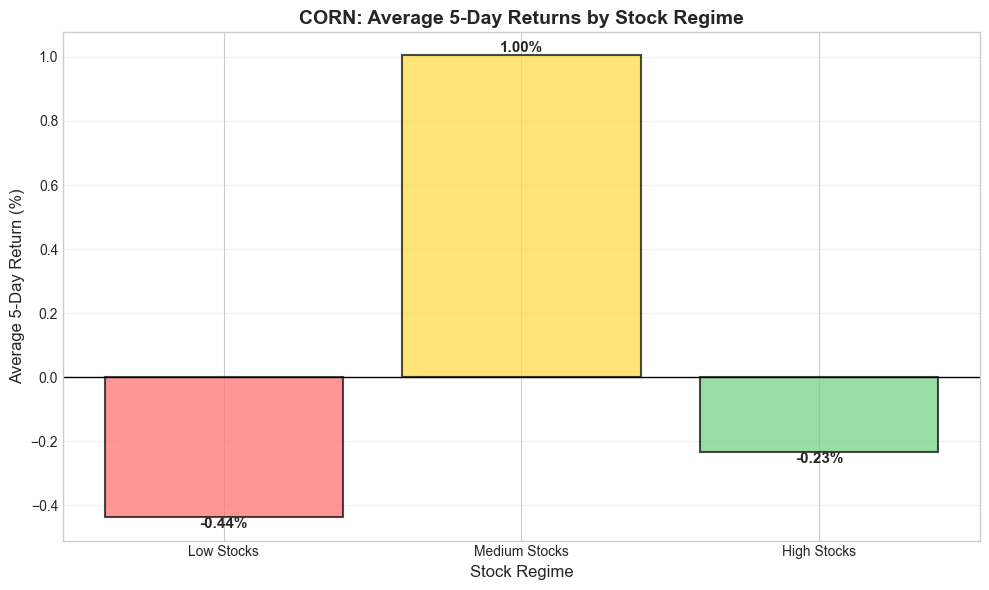

Price behavior differs depending on supply conditions.


In [17]:
# CORN: Returns by stock regime
corn_clean = corn.dropna(subset=['ending_stocks', 'ret_5d'])
corn_clean['stock_regime'] = pd.qcut(corn_clean['ending_stocks'], q=3, labels=['Low Stocks', 'Medium Stocks', 'High Stocks'])

fig, ax = plt.subplots(figsize=(10, 6))
returns_by_regime = corn_clean.groupby('stock_regime')['ret_5d'].mean() * 100  # Convert to percentage
colors = ['#FF6B6B', '#FFD93D', '#6BCF7F']
bars = ax.bar(returns_by_regime.index, returns_by_regime.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Average 5-Day Return (%)', fontsize=12)
ax.set_xlabel('Stock Regime', fontsize=12)
ax.set_title('CORN: Average 5-Day Returns by Stock Regime', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Price behavior differs depending on supply conditions.")


/var/folders/3j/0xbmd_c918x585z1bkf86vtw0000gn/T/ipykernel_36216/1248139964.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soy_clean['stock_regime'] = pd.qcut(soy_clean['ending_stocks'], q=3, labels=['Low Stocks', 'Medium Stocks', 'High Stocks'])
/var/folders/3j/0xbmd_c918x585z1bkf86vtw0000gn/T/ipykernel_36216/1248139964.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  returns_by_regime = soy_clean.groupby('stock_regime')['ret_5d'].mean() * 100


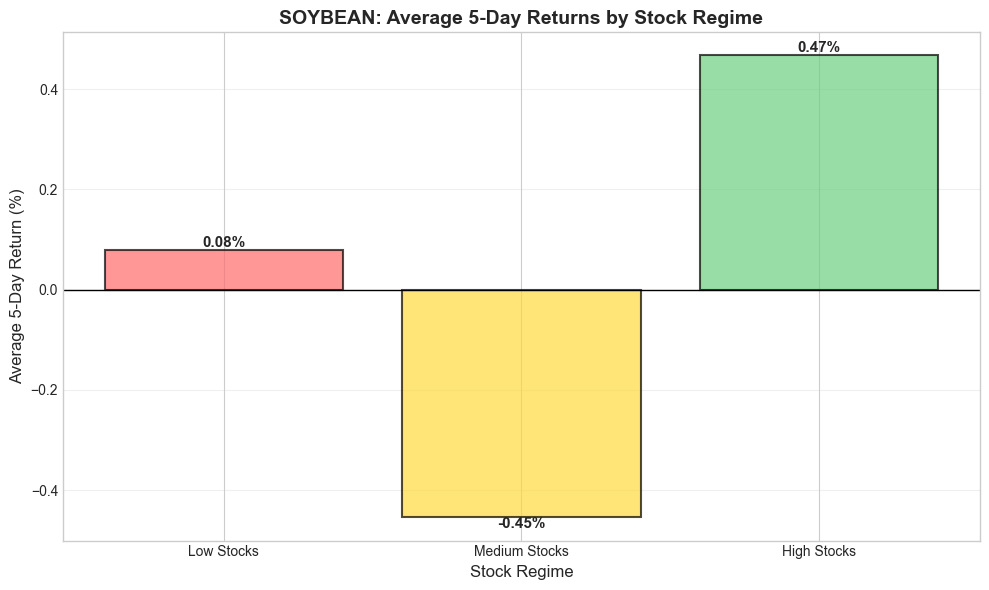

In [18]:
# SOYBEAN: Returns by stock regime
soy_clean = soy.dropna(subset=['ending_stocks', 'ret_5d'])
soy_clean['stock_regime'] = pd.qcut(soy_clean['ending_stocks'], q=3, labels=['Low Stocks', 'Medium Stocks', 'High Stocks'])

fig, ax = plt.subplots(figsize=(10, 6))
returns_by_regime = soy_clean.groupby('stock_regime')['ret_5d'].mean() * 100
colors = ['#FF6B6B', '#FFD93D', '#6BCF7F']
bars = ax.bar(returns_by_regime.index, returns_by_regime.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Average 5-Day Return (%)', fontsize=12)
ax.set_xlabel('Stock Regime', fontsize=12)
ax.set_title('SOYBEAN: Average 5-Day Returns by Stock Regime', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


/var/folders/3j/0xbmd_c918x585z1bkf86vtw0000gn/T/ipykernel_36216/3513282864.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wheat_clean['stock_regime'] = pd.qcut(wheat_clean['ending_stocks_total'], q=3, labels=['Low Stocks', 'Medium Stocks', 'High Stocks'])
/var/folders/3j/0xbmd_c918x585z1bkf86vtw0000gn/T/ipykernel_36216/3513282864.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  returns_by_regime = wheat_clean.groupby('stock_regime')['ret_5d'].mean() * 100


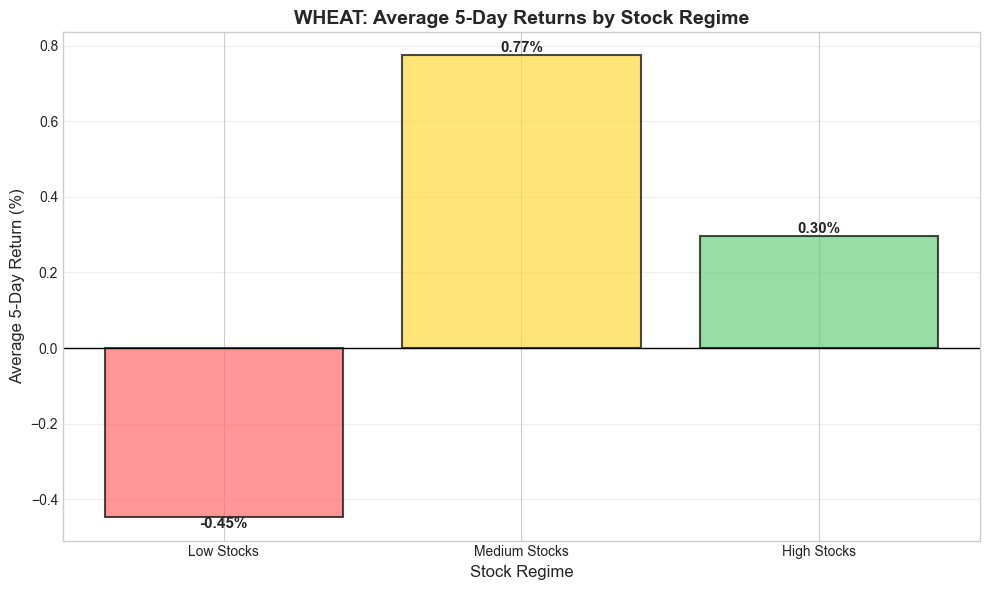

In [19]:
# WHEAT: Returns by stock regime
wheat_clean = wheat.dropna(subset=['ending_stocks_total', 'ret_5d'])
wheat_clean['stock_regime'] = pd.qcut(wheat_clean['ending_stocks_total'], q=3, labels=['Low Stocks', 'Medium Stocks', 'High Stocks'])

fig, ax = plt.subplots(figsize=(10, 6))
returns_by_regime = wheat_clean.groupby('stock_regime')['ret_5d'].mean() * 100
colors = ['#FF6B6B', '#FFD93D', '#6BCF7F']
bars = ax.bar(returns_by_regime.index, returns_by_regime.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Average 5-Day Return (%)', fontsize=12)
ax.set_xlabel('Stock Regime', fontsize=12)
ax.set_title('WHEAT: Average 5-Day Returns by Stock Regime', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## GRAPH 7 — Volume & OI Dominance

Shows which part of the curve traders are focusing on.


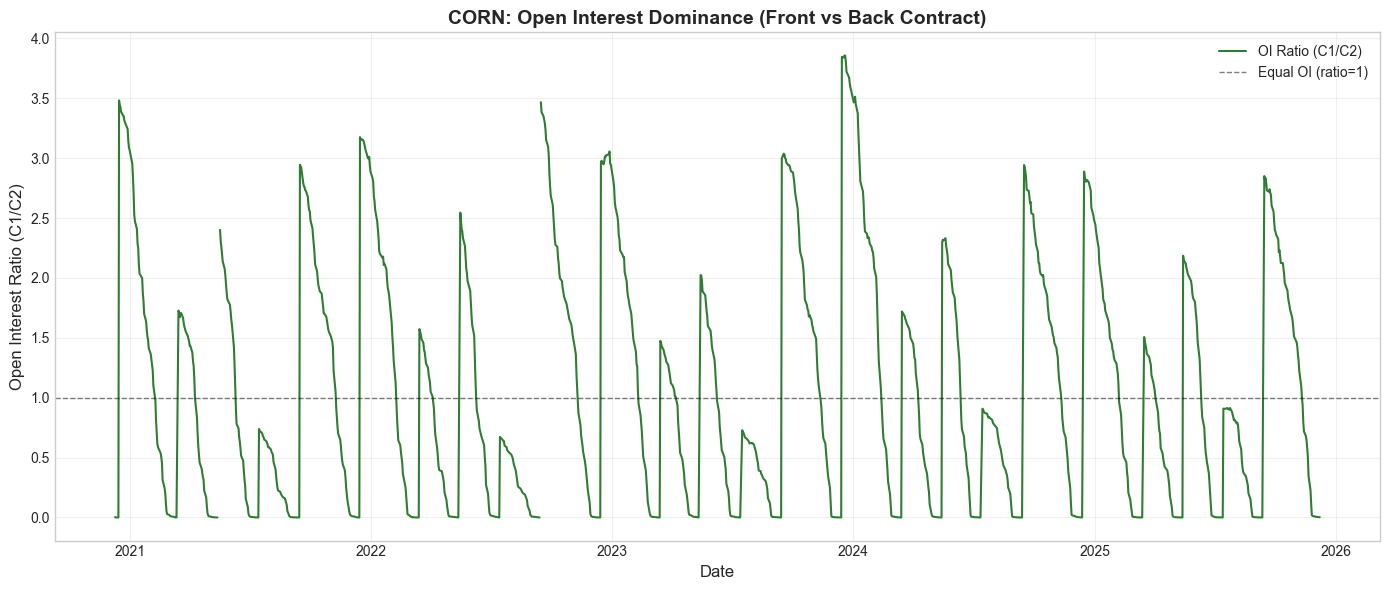

This shows which part of the curve traders are focusing on.
Ratio > 1: More OI in front contract
Ratio < 1: More OI in back contract


In [20]:
# CORN: OI Ratio (dominance of front vs back contract)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(corn['date'], corn['oi_ratio'], linewidth=1.5, color='#2E7D32', label='OI Ratio (C1/C2)')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal OI (ratio=1)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Open Interest Ratio (C1/C2)', fontsize=12)
ax.set_title('CORN: Open Interest Dominance (Front vs Back Contract)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("This shows which part of the curve traders are focusing on.")
print("Ratio > 1: More OI in front contract")
print("Ratio < 1: More OI in back contract")


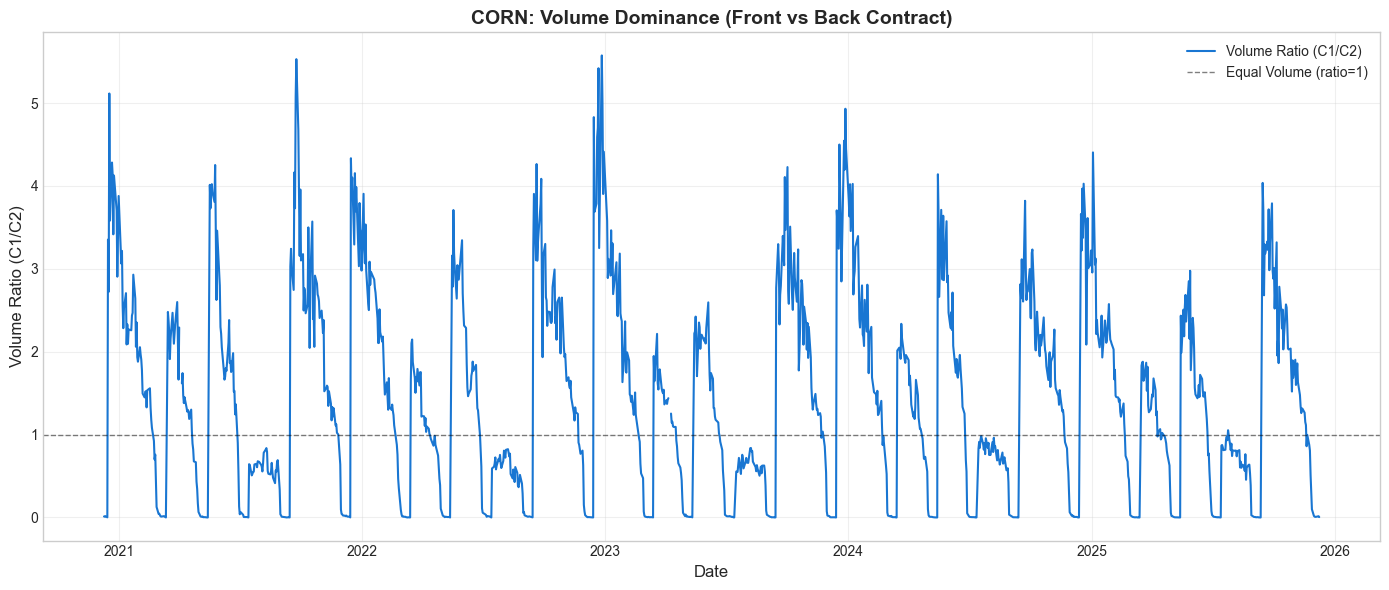

In [21]:
# CORN: Volume Ratio
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(corn['date'], corn['vol_ratio'], linewidth=1.5, color='#1976D2', label='Volume Ratio (C1/C2)')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal Volume (ratio=1)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume Ratio (C1/C2)', fontsize=12)
ax.set_title('CORN: Volume Dominance (Front vs Back Contract)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


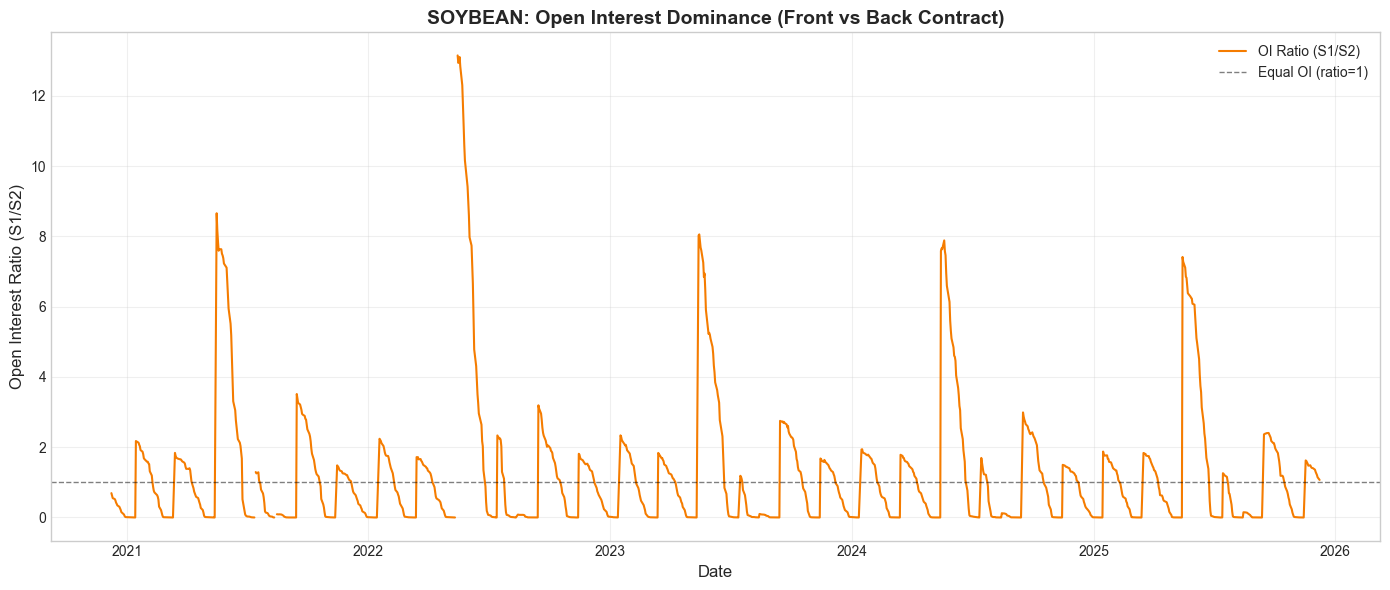

In [22]:
# SOYBEAN: OI Ratio
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(soy['date'], soy['oi_ratio'], linewidth=1.5, color='#F57C00', label='OI Ratio (S1/S2)')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal OI (ratio=1)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Open Interest Ratio (S1/S2)', fontsize=12)
ax.set_title('SOYBEAN: Open Interest Dominance (Front vs Back Contract)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


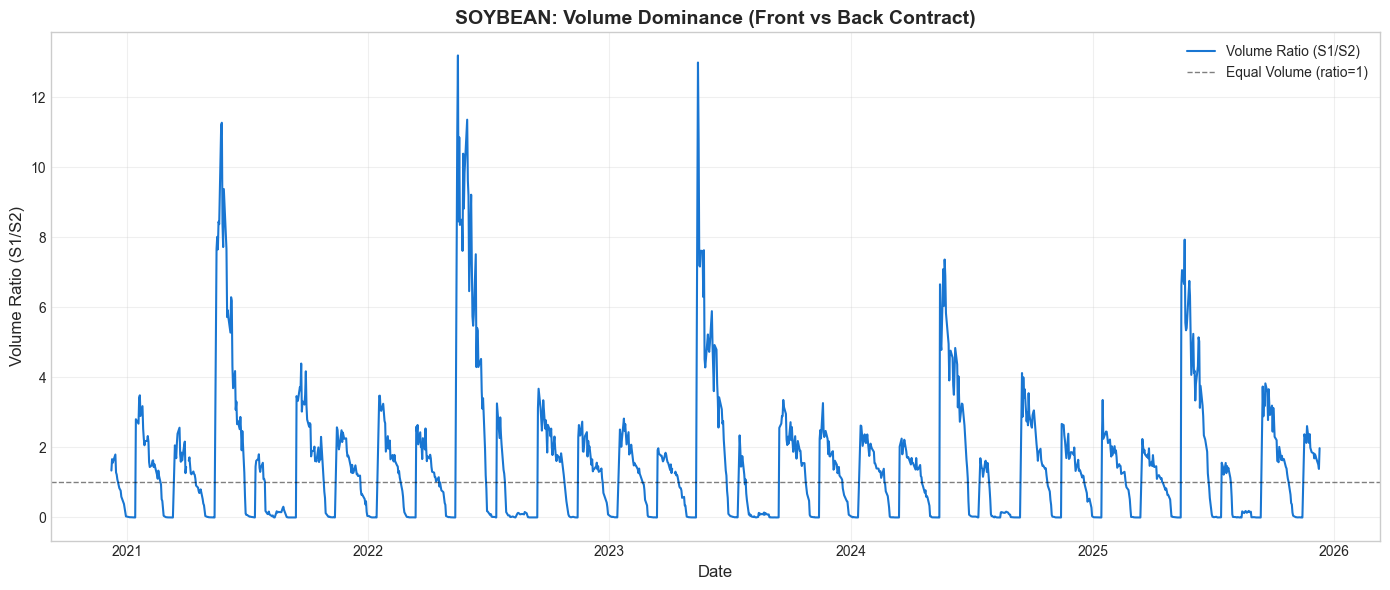

In [23]:
# SOYBEAN: Volume Ratio
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(soy['date'], soy['vol_ratio'], linewidth=1.5, color='#1976D2', label='Volume Ratio (S1/S2)')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal Volume (ratio=1)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume Ratio (S1/S2)', fontsize=12)
ax.set_title('SOYBEAN: Volume Dominance (Front vs Back Contract)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


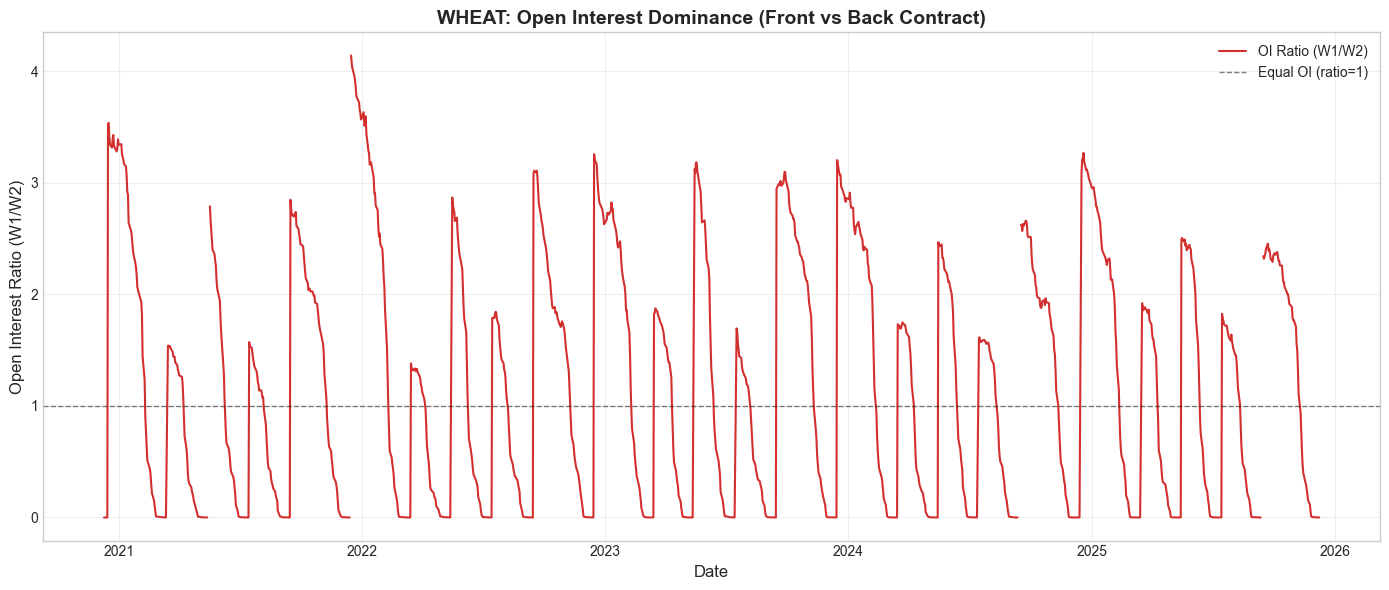

In [24]:
# WHEAT: OI Ratio
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wheat['date'], wheat['oi_ratio'], linewidth=1.5, color='#D32F2F', label='OI Ratio (W1/W2)')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal OI (ratio=1)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Open Interest Ratio (W1/W2)', fontsize=12)
ax.set_title('WHEAT: Open Interest Dominance (Front vs Back Contract)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


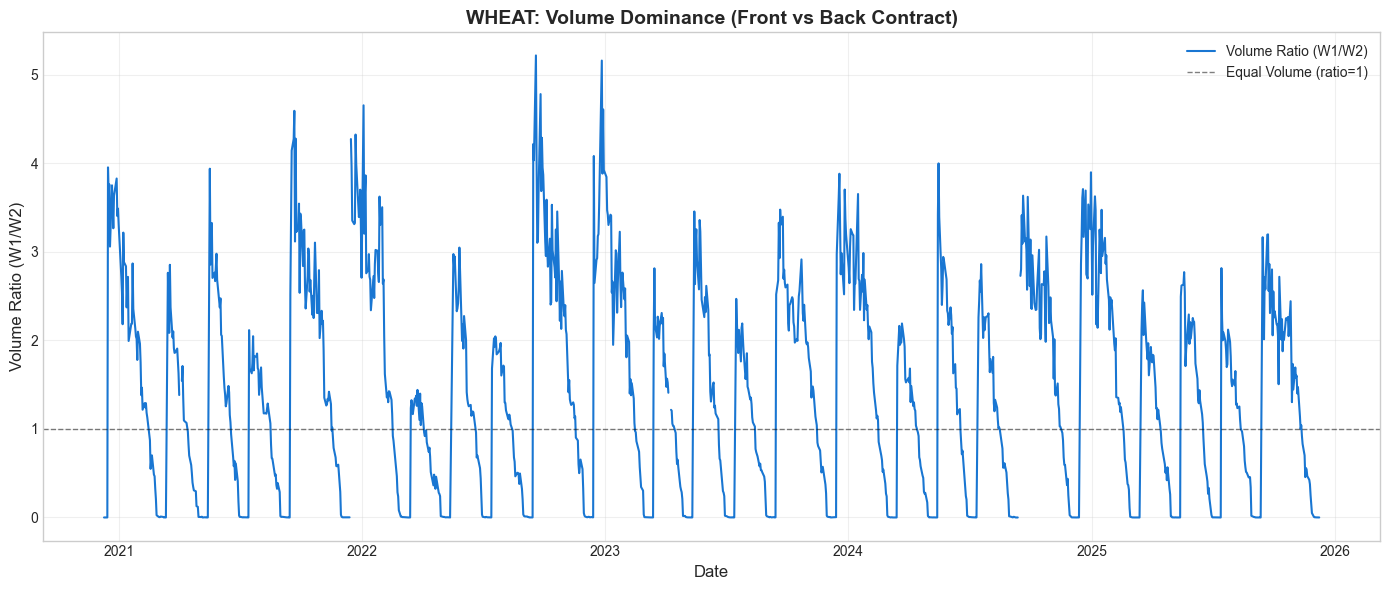

In [25]:
# WHEAT: Volume Ratio
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wheat['date'], wheat['vol_ratio'], linewidth=1.5, color='#1976D2', label='Volume Ratio (W1/W2)')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal Volume (ratio=1)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume Ratio (W1/W2)', fontsize=12)
ax.set_title('WHEAT: Volume Dominance (Front vs Back Contract)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Summary

All visualizations created for:
- ✅ **CORN**: 7 graphs showing price, spreads, roll pressure, stocks, relationships, returns by regime, and OI/volume dominance
- ✅ **SOYBEAN**: 7 graphs showing price, spreads, roll pressure, stocks, relationships, returns by regime, and OI/volume dominance  
- ✅ **WHEAT**: 7 graphs showing price, spreads, roll pressure, stocks, relationships, returns by regime, and OI/volume dominance

**Key insights visualized:**
1. Price movements over time (baseline context)
2. Forward curve structure (contango vs backwardation)
3. Money flow between contracts (roll pressure)
4. Fundamental supply reality (ending stocks)
5. Economics-prices relationship (spread vs stocks)
6. Regime-dependent returns (strategy foundation)
7. Market focus indicators (OI and volume dominance)
